# Illegal Mining Detection — Inference Visualizer
**Notebook:** `inference_visualizer.ipynb`

### What this notebook does
1. Takes a **full large Sentinel-2 GeoTIFF** as input
2. Slides a **64×64 window** across the entire image
3. Runs every patch through **best_model.pth** (EfficientNetV2-S)
4. **Stitches predictions back** onto the original image
5. Outputs:
   - `output_overlay.png` — satellite image with **red highlights** on detected mines
   - `output_heatmap.png` — confidence heatmap showing intensity of mining activity
   - `output_coordinates.csv` — **GPS coordinates** of every detected mine patch
   - `output_georef.tif` — geo-referenced output (openable in QGIS)

### This is what your sir asked for
Input = big satellite image → Output = map showing exactly where the mines are


## Cell 1 — Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

# rasterio reads GeoTIFF files and gives us GPS coordinates
try:
    import rasterio
    from rasterio.transform import xy as rio_xy
    from rasterio.crs import CRS
    import rasterio.features
    HAS_RASTERIO = True
    print('rasterio available — GPS coordinates will be extracted')
except ImportError:
    HAS_RASTERIO = False
    print('rasterio not found — run: pip install rasterio')
    print('GPS coordinates will be skipped but image overlay will still work')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


rasterio available — GPS coordinates will be extracted
Device: cuda


## Cell 2 — Config

In [2]:
# ── INPUT: path to your large Sentinel-2 GeoTIFF ────────────────────────
GEOTIFF_PATH = r"R:\ai project image\data image big\big 2021\T45QUE_20211223T045221_TCI_10m.jp2"

SITE_ID = 'T45QUE'
YEAR    = '2021'

# ── MODEL ─────────────────────────────────────────────────────────────────
MODEL_PATH   = 'saved_models/best_model.pth'   # EfficientNet-B0
NUM_CLASSES  = 2

# ── PATCH SETTINGS ────────────────────────────────────────────────────────
PATCH_SIZE   = 64     # must match training patch size
STRIDE       = 32     # 50% overlap — smoother output

# ── DETECTION THRESHOLD ───────────────────────────────────────────────────
THRESHOLD    = 0.6    # raised slightly for large scenes — reduces false positives

# ── OUTPUT ────────────────────────────────────────────────────────────────
OUTPUT_DIR   = 'inference_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'GeoTIFF   : {GEOTIFF_PATH}')
print(f'Model     : {MODEL_PATH}')
print(f'Patch size: {PATCH_SIZE}px  Stride: {STRIDE}px')
print(f'Threshold : {THRESHOLD}')
print(f'Output dir: {OUTPUT_DIR}')


GeoTIFF   : R:\ai project image\data image big\big 2021\T45QUE_20211223T045221_TCI_10m.jp2
Model     : saved_models/best_model.pth
Patch size: 64px  Stride: 32px
Threshold : 0.6
Output dir: inference_output


## Cell 3 — Load Model

In [3]:
def load_model(model_path, num_classes=2):
    """Load EfficientNet-B0 with trained weights."""
    model = models.efficientnet_b0(weights=None)
    in_f  = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),                       # matches retrained B0
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    print(f'Model loaded from {model_path}')
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Architecture : EfficientNet-B0  ({total_params/1e6:.1f}M parameters)')
    return model

model = load_model(MODEL_PATH, NUM_CLASSES)
print('Ready for inference.')


Model loaded from saved_models/best_model.pth
Architecture : EfficientNet-B0  (4.3M parameters)
Ready for inference.


## Cell 4 — Load GeoTIFF

GeoTIFF info:
  Size       : 10980 x 10980 pixels
  Bands      : 3
  CRS        : EPSG:32645
  Bounds     : BoundingBox(left=300000.0, bottom=2390220.0, right=409800.0, top=2500020.0)
  Resolution : (10.0, 10.0) meters/pixel

Image loaded: 10980 x 10980 pixels


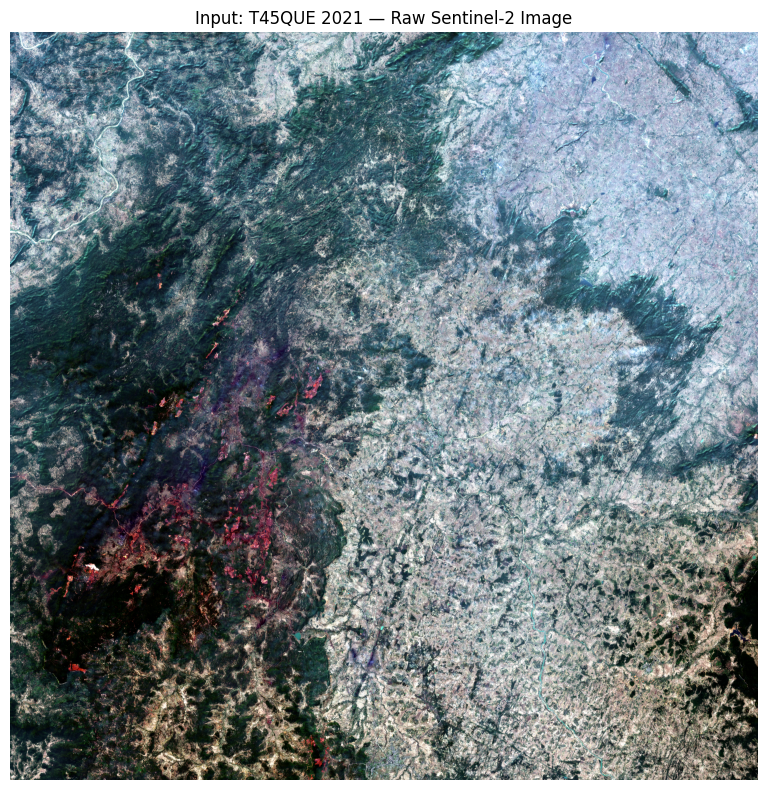

Saved: inference_output/input_preview.png


In [4]:
def load_geotiff(path):
    """
    Load a GeoTIFF and return:
      - rgb_array : (H, W, 3) uint8 numpy array for display
      - transform : rasterio affine transform (pixel -> GPS)
      - crs       : coordinate reference system
    """
    if HAS_RASTERIO:
        with rasterio.open(path) as src:
            print(f'GeoTIFF info:')
            print(f'  Size       : {src.width} x {src.height} pixels')
            print(f'  Bands      : {src.count}')
            print(f'  CRS        : {src.crs}')
            print(f'  Bounds     : {src.bounds}')
            print(f'  Resolution : {src.res} meters/pixel')

            # Read bands — Sentinel-2 RGB = B04, B03, B02
            if src.count >= 3:
                r = src.read(1).astype(np.float32)
                g = src.read(2).astype(np.float32)
                b = src.read(3).astype(np.float32)
            else:
                # Single band — replicate to RGB
                band = src.read(1).astype(np.float32)
                r = g = b = band

            transform = src.transform
            crs       = src.crs

        # Stack and normalise to 0-255
        rgb = np.stack([r, g, b], axis=-1)
        for i in range(3):
            p2, p98 = np.percentile(rgb[:,:,i], (2, 98))
            rgb[:,:,i] = np.clip((rgb[:,:,i] - p2) / (p98 - p2 + 1e-8), 0, 1)
        rgb_uint8 = (rgb * 255).astype(np.uint8)

        return rgb_uint8, transform, crs

    else:
        # Fallback: load with PIL (no GPS coordinates)
        img = Image.open(path).convert('RGB')
        rgb_uint8 = np.array(img)
        print(f'Loaded with PIL: {rgb_uint8.shape}')
        print('WARNING: No GPS coordinates (rasterio not available)')
        return rgb_uint8, None, None


rgb_image, geo_transform, crs = load_geotiff(GEOTIFF_PATH)
H, W = rgb_image.shape[:2]
print(f'\nImage loaded: {W} x {H} pixels')

# Preview the raw image
plt.figure(figsize=(10, 8))
plt.imshow(rgb_image)
plt.title(f'Input: {SITE_ID} {YEAR} — Raw Sentinel-2 Image')
plt.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/input_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/input_preview.png')


## Cell 5 — Sliding Window Inference

This is the core step. We slide a 64×64 window across the full image, run each patch through the model, and record the mining probability for each patch position.

In [5]:
# Transform for each patch — must match EfficientNetV2-S training transform
patch_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # EfficientNet-B0 input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

def run_sliding_window(image, model, patch_size, stride, threshold, batch_size=64):
    """
    Slide a patch_size window across image with given stride.
    Returns:
      - prob_map   : (H, W) float array of mining probability per pixel
      - detections : list of dicts with patch info
    """
    H, W      = image.shape[:2]
    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)  # for averaging overlaps
    detections = []

    # Collect all patch positions
    positions = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            positions.append((y, x))

    total_patches = len(positions)
    print(f'Total patches to process : {total_patches:,}')
    print(f'Running inference...')

    # Process in batches for speed
    model.eval()
    patches_batch = []
    pos_batch     = []
    processed     = 0

    with torch.no_grad():
        for i, (y, x) in enumerate(positions):
            # Extract patch
            patch = image[y:y+patch_size, x:x+patch_size]
            patch_pil = Image.fromarray(patch)
            patch_tensor = patch_transform(patch_pil)
            patches_batch.append(patch_tensor)
            pos_batch.append((y, x))

            # When batch is full or last patch
            if len(patches_batch) == batch_size or i == len(positions) - 1:
                batch_tensor = torch.stack(patches_batch).to(device)
                outputs      = model(batch_tensor)
                probs        = torch.softmax(outputs, dim=1)[:, 0]  # index 0 = mining (ImageFolder: mining < non mining alphabetically)
                probs_np     = probs.cpu().numpy()

                for (py, px), prob in zip(pos_batch, probs_np):
                    # Write probability to all pixels this patch covers
                    prob_map [py:py+patch_size, px:px+patch_size] += prob
                    count_map[py:py+patch_size, px:px+patch_size] += 1.0

                    if prob >= threshold:
                        detections.append({
                            'pixel_y'   : py,
                            'pixel_x'   : px,
                            'confidence': float(prob),
                            'label'     : 'Mining'
                        })

                patches_batch = []
                pos_batch     = []
                processed    += batch_size

                # Progress
                pct = min(100, (i+1)/total_patches*100)
                if (i+1) % 500 == 0 or i == len(positions)-1:
                    print(f'  [{pct:5.1f}%]  {i+1:,}/{total_patches:,} patches  '
                          f'| Mining detections so far: {len(detections)}')

    # Average overlapping predictions
    count_map = np.maximum(count_map, 1)
    prob_map  = prob_map / count_map

    return prob_map, detections


prob_map, detections = run_sliding_window(
    rgb_image, model, PATCH_SIZE, STRIDE, THRESHOLD, batch_size=64
)

print(f'\nInference complete!')
print(f'Mining patches detected : {len(detections):,}')
total = ((H - PATCH_SIZE) // STRIDE + 1) * ((W - PATCH_SIZE) // STRIDE + 1)
print(f'Total patches scanned   : {total:,}')
print(f'Mining coverage         : {len(detections)/total*100:.1f}%')


Total patches to process : 116,964
Running inference...
  [  6.8%]  8,000/116,964 patches  | Mining detections so far: 1454
  [ 13.7%]  16,000/116,964 patches  | Mining detections so far: 2672
  [ 20.5%]  24,000/116,964 patches  | Mining detections so far: 3902
  [ 27.4%]  32,000/116,964 patches  | Mining detections so far: 5102
  [ 34.2%]  40,000/116,964 patches  | Mining detections so far: 6259
  [ 41.0%]  48,000/116,964 patches  | Mining detections so far: 7333
  [ 47.9%]  56,000/116,964 patches  | Mining detections so far: 8462
  [ 54.7%]  64,000/116,964 patches  | Mining detections so far: 9869
  [ 61.6%]  72,000/116,964 patches  | Mining detections so far: 10824
  [ 68.4%]  80,000/116,964 patches  | Mining detections so far: 11887
  [ 75.2%]  88,000/116,964 patches  | Mining detections so far: 12577
  [ 82.1%]  96,000/116,964 patches  | Mining detections so far: 12851
  [ 88.9%]  104,000/116,964 patches  | Mining detections so far: 13142
  [ 95.8%]  112,000/116,964 patches  | Min

## Cell 6 — Generate Overlay Image

This is the visual output — the satellite image with red highlights on detected mining areas.

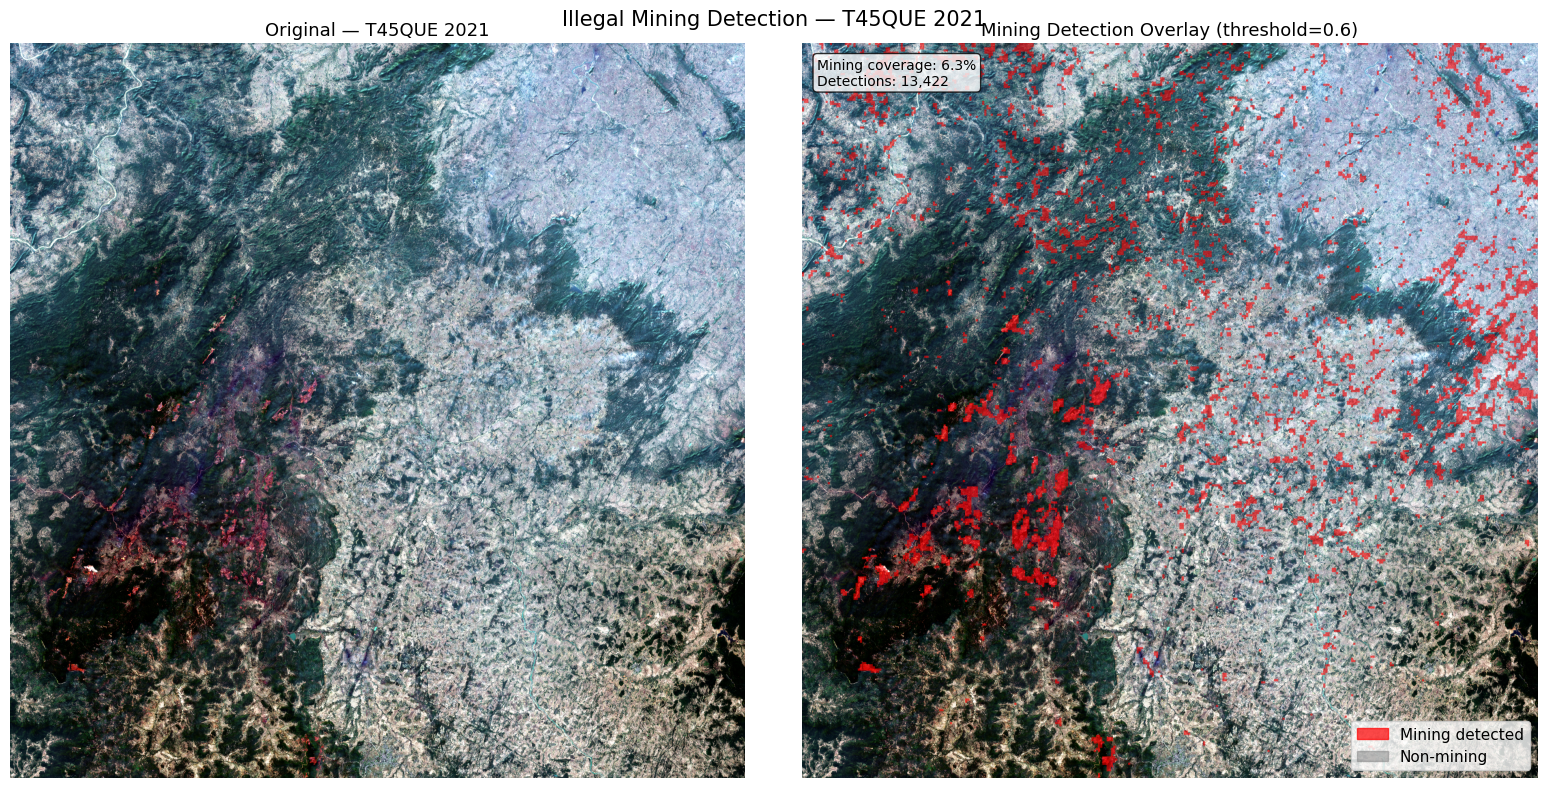

Saved: inference_output/T45QUE_2021_overlay.png


In [6]:
def create_overlay(rgb_image, prob_map, threshold, alpha=0.45):
    """
    Overlay red highlights on mining areas over the original satellite image.
    alpha controls transparency of the overlay (0=invisible, 1=solid).
    """
    overlay = rgb_image.copy().astype(np.float32)
    H, W    = rgb_image.shape[:2]

    # Binary mining mask
    mining_mask = prob_map >= threshold

    # Red overlay on mining pixels
    overlay[mining_mask, 0] = np.clip(overlay[mining_mask, 0] * 0.4 + 255 * 0.6, 0, 255)
    overlay[mining_mask, 1] = np.clip(overlay[mining_mask, 1] * 0.4,              0, 255)
    overlay[mining_mask, 2] = np.clip(overlay[mining_mask, 2] * 0.4,              0, 255)

    return overlay.astype(np.uint8), mining_mask


overlay_image, mining_mask = create_overlay(rgb_image, prob_map, THRESHOLD)

# Plot side by side: original vs overlay
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(rgb_image)
axes[0].set_title(f'Original — {SITE_ID} {YEAR}', fontsize=13)
axes[0].axis('off')

axes[1].imshow(overlay_image)
axes[1].set_title(f'Mining Detection Overlay (threshold={THRESHOLD})', fontsize=13)
axes[1].axis('off')

# Legend
red_patch   = mpatches.Patch(color='red',  alpha=0.7, label='Mining detected')
other_patch = mpatches.Patch(color='gray', alpha=0.5, label='Non-mining')
axes[1].legend(handles=[red_patch, other_patch],
               loc='lower right', fontsize=11, framealpha=0.8)

# Stats annotation
coverage = mining_mask.sum() / mining_mask.size * 100
axes[1].text(0.02, 0.98,
             f'Mining coverage: {coverage:.1f}%\nDetections: {len(detections):,}',
             transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'Illegal Mining Detection — {SITE_ID} {YEAR}', fontsize=15)
plt.tight_layout()

out_overlay = f'{OUTPUT_DIR}/{SITE_ID}_{YEAR}_overlay.png'
plt.savefig(out_overlay, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_overlay}')


## Cell 7 — Confidence Heatmap

Shows the intensity of mining probability across the scene — useful to identify the hottest areas.

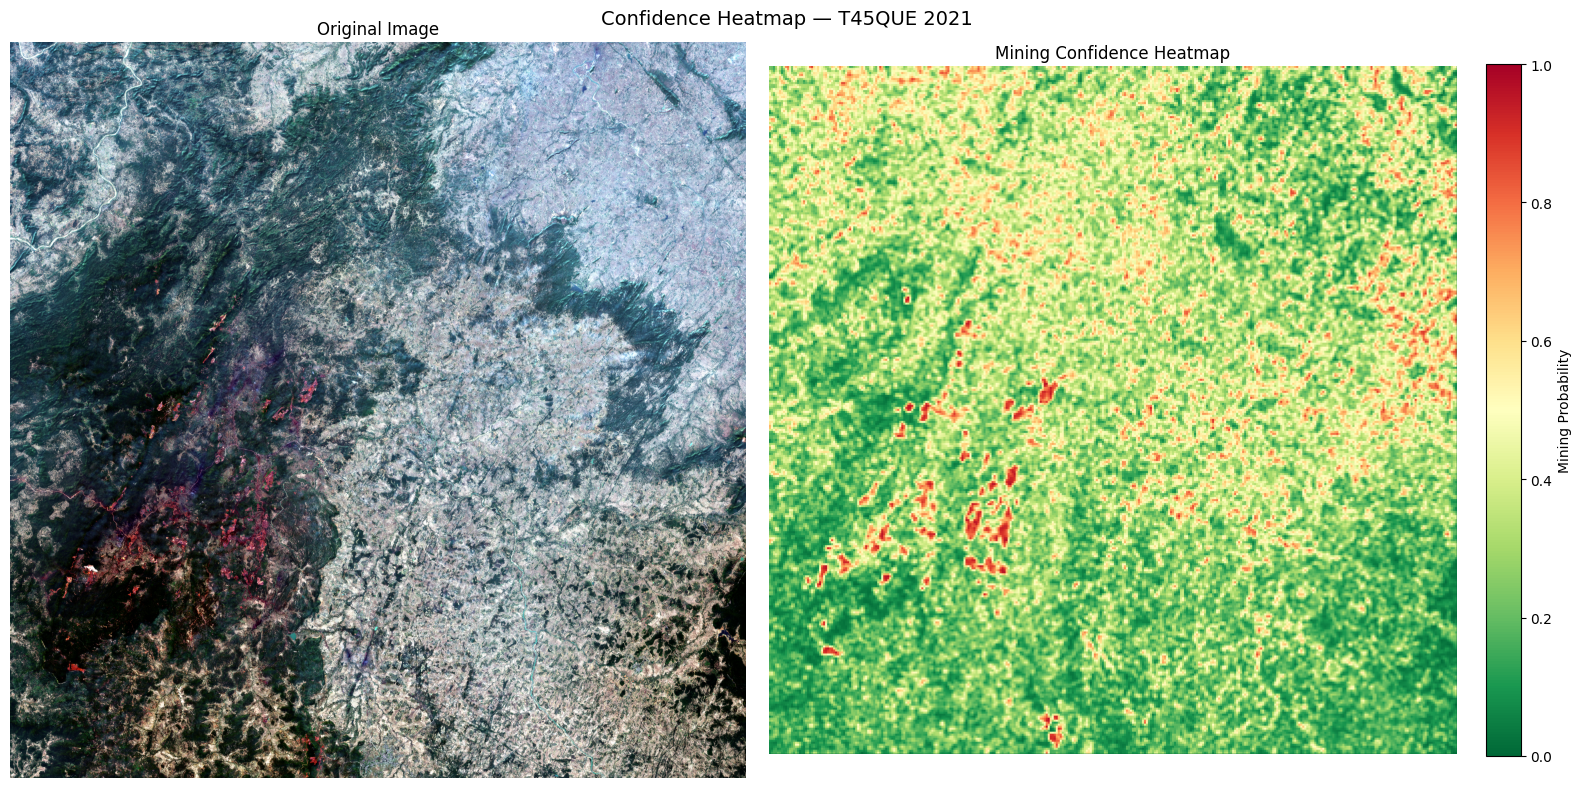

Saved: inference_output/T45QUE_2021_heatmap.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(rgb_image)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

# Heatmap
im = axes[1].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title('Mining Confidence Heatmap', fontsize=12)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
             label='Mining Probability')

plt.suptitle(f'Confidence Heatmap — {SITE_ID} {YEAR}', fontsize=14)
plt.tight_layout()

out_heat = f'{OUTPUT_DIR}/{SITE_ID}_{YEAR}_heatmap.png'
plt.savefig(out_heat, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_heat}')


## Cell 8 — Extract GPS Coordinates

Converts pixel positions of detected mine patches back to real-world latitude/longitude using the GeoTIFF's embedded coordinate system.

In [8]:
def pixel_to_latlon(row, col, transform, crs):
    """Convert pixel (row, col) to (lat, lon) using rasterio."""
    if transform is None:
        return None, None
    try:
        from pyproj import Transformer
        # Get projected coordinates from pixel
        x_proj, y_proj = rio_xy(transform, row, col)
        # Convert to WGS84 lat/lon
        proj_crs = CRS.from_user_input(crs)
        wgs84    = CRS.from_epsg(4326)
        if proj_crs != wgs84:
            transformer = Transformer.from_crs(proj_crs, wgs84, always_xy=True)
            lon, lat    = transformer.transform(x_proj, y_proj)
        else:
            lon, lat = x_proj, y_proj
        return round(lat, 6), round(lon, 6)
    except Exception as e:
        # Fallback: return projected coords
        x_proj, y_proj = rio_xy(transform, row, col)
        return round(y_proj, 2), round(x_proj, 2)


# Build CSV of all detections
records = []
for det in detections:
    py = det['pixel_y']
    px = det['pixel_x']

    if HAS_RASTERIO and geo_transform is not None:
        lat, lon = pixel_to_latlon(py + PATCH_SIZE//2,
                                   px + PATCH_SIZE//2,
                                   geo_transform, crs)
    else:
        lat, lon = None, None

    records.append({
        'site_id'    : SITE_ID,
        'year'       : YEAR,
        'pixel_row'  : py,
        'pixel_col'  : px,
        'latitude'   : lat,
        'longitude'  : lon,
        'confidence' : round(det['confidence'], 4),
        'label'      : 'Mining'
    })

df = pd.DataFrame(records)
df = df.sort_values('confidence', ascending=False).reset_index(drop=True)

out_csv = f'{OUTPUT_DIR}/{SITE_ID}_{YEAR}_coordinates.csv'
df.to_csv(out_csv, index=False)

print(f'GPS coordinates saved: {out_csv}')
print(f'Total mine detections: {len(df)}')
print()
print(df.head(10).to_string(index=False))


GPS coordinates saved: inference_output/T45QUE_2021_coordinates.csv
Total mine detections: 13422

site_id year  pixel_row  pixel_col  latitude  longitude  confidence  label
 T45QUE 2021       6496       3904 22.009851  85.443805      0.9847 Mining
 T45QUE 2021       8064       3712 21.868064  85.426768      0.9837 Mining
 T45QUE 2021       6656       3808 21.995312  85.434666      0.9837 Mining
 T45QUE 2021       7520        960 21.914430  85.159892      0.9832 Mining
 T45QUE 2021       8128       1888 21.860505  85.250368      0.9827 Mining
 T45QUE 2021       7968        896 21.873906  85.154219      0.9827 Mining
 T45QUE 2021       7520       3744 21.917224  85.429326      0.9817 Mining
 T45QUE 2021       5344       4288 22.114240  85.479883      0.9798 Mining
 T45QUE 2021      10400       4416 21.657720  85.497082      0.9796 Mining
 T45QUE 2021       4800       9280 22.167167  85.963420      0.9794 Mining


## Cell 9 — Save Geo-Referenced Output (QGIS-ready)

Saves the overlay as a proper GeoTIFF so you can open it directly in QGIS and it will align perfectly with the original satellite scene.

In [9]:
if HAS_RASTERIO and geo_transform is not None:
    out_georef = f'{OUTPUT_DIR}/{SITE_ID}_{YEAR}_overlay_georef.tif'

    with rasterio.open(GEOTIFF_PATH) as src:
        profile = src.profile.copy()
        profile.update({
            'count'  : 3,
            'dtype'  : 'uint8',
            'driver' : 'GTiff'
        })

    with rasterio.open(out_georef, 'w', **profile) as dst:
        dst.write(overlay_image[:,:,0], 1)   # R
        dst.write(overlay_image[:,:,1], 2)   # G
        dst.write(overlay_image[:,:,2], 3)   # B

    print(f'Geo-referenced overlay saved: {out_georef}')
    print('You can open this directly in QGIS — it will align with the original scene.')
else:
    print('Skipping GeoTIFF output (rasterio not available or no geo_transform).')


Geo-referenced overlay saved: inference_output/T45QUE_2021_overlay_georef.tif
You can open this directly in QGIS — it will align with the original scene.


## Cell 10 — Top Mining Hotspots

Shows the top 10 highest-confidence mine detections with their GPS coordinates — the most certain mines in the scene.

In [10]:
print('='*60)
print(f'  TOP 10 HIGHEST CONFIDENCE DETECTIONS — {SITE_ID} {YEAR}')
print('='*60)

top10 = df.head(10)
for i, row in top10.iterrows():
    coord_str = (f'Lat: {row["latitude"]:.5f}  Lon: {row["longitude"]:.5f}'
                 if row['latitude'] is not None
                 else f'Pixel ({row["pixel_row"]}, {row["pixel_col"]})')
    print(f'  #{i+1:02d}  {coord_str}  |  Confidence: {row["confidence"]:.4f}')

print()
print(f'Total mining patches : {len(df)}')
coverage_pct = mining_mask.sum() / mining_mask.size * 100
print(f'Mining coverage      : {coverage_pct:.2f}% of scanned area')
print(f'Model used           : EfficientNet-B0 (best_model.pth)')
print(f'Confidence threshold : {THRESHOLD}')


  TOP 10 HIGHEST CONFIDENCE DETECTIONS — T45QUE 2021
  #01  Lat: 22.00985  Lon: 85.44380  |  Confidence: 0.9847
  #02  Lat: 21.86806  Lon: 85.42677  |  Confidence: 0.9837
  #03  Lat: 21.99531  Lon: 85.43467  |  Confidence: 0.9837
  #04  Lat: 21.91443  Lon: 85.15989  |  Confidence: 0.9832
  #05  Lat: 21.86050  Lon: 85.25037  |  Confidence: 0.9827
  #06  Lat: 21.87391  Lon: 85.15422  |  Confidence: 0.9827
  #07  Lat: 21.91722  Lon: 85.42933  |  Confidence: 0.9817
  #08  Lat: 22.11424  Lon: 85.47988  |  Confidence: 0.9798
  #09  Lat: 21.65772  Lon: 85.49708  |  Confidence: 0.9796
  #10  Lat: 22.16717  Lon: 85.96342  |  Confidence: 0.9794

Total mining patches : 13422
Mining coverage      : 6.35% of scanned area
Model used           : EfficientNet-B0 (best_model.pth)
Confidence threshold : 0.6


## Cell 11 — Summary of All Output Files

In [11]:
print('='*55)
print('  OUTPUT FILES')
print('='*55)
for f in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path) / 1024
    unit = 'KB'
    if size > 1024:
        size /= 1024; unit = 'MB'
    print(f'  {f:<45} {size:.1f} {unit}')

print()
print('What each file is:')
print(f'  input_preview.png        -> raw satellite image (for reference)')
print(f'  *_overlay.png            -> satellite + RED highlights on mines')
print(f'  *_heatmap.png            -> confidence intensity map')
print(f'  *_coordinates.csv        -> GPS coordinates of every mine patch')
print(f'  *_overlay_georef.tif     -> QGIS-ready geo-referenced overlay')
print()
print('Next step -> temporal_analysis.ipynb')
print('  Run this same pipeline year by year (2019-2023)')
print('  Plot how mining area expanded over time')


  OUTPUT FILES
  SITE-03_2023_coordinates.csv                  207.2 KB
  SITE-03_2023_heatmap.png                      6.7 MB
  SITE-03_2023_overlay.png                      11.2 MB
  SITE-03_2023_overlay_georef.tif               363.0 MB
  T45QUE_2021_coordinates.csv                   741.4 KB
  T45QUE_2021_heatmap.png                       7.4 MB
  T45QUE_2021_overlay.png                       10.7 MB
  T45QUE_2021_overlay_georef.tif                363.0 MB
  input_preview.png                             3.2 MB
  temporal                                      4.0 KB

What each file is:
  input_preview.png        -> raw satellite image (for reference)
  *_overlay.png            -> satellite + RED highlights on mines
  *_heatmap.png            -> confidence intensity map
  *_coordinates.csv        -> GPS coordinates of every mine patch
  *_overlay_georef.tif     -> QGIS-ready geo-referenced overlay

Next step -> temporal_analysis.ipynb
  Run this same pipeline year by year (2019-2023)
